In [51]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [52]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

In [53]:
print(X_train.shape) #Display Dataset Shape
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


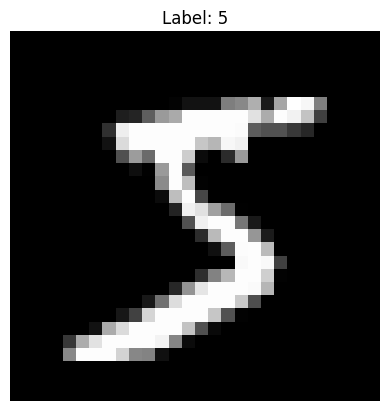

In [54]:
plt.imshow(X_train[0], cmap="gray")
plt.title(f"Label: {y_train[0]}")
plt.axis("off")
plt.show() #Display a Sample Image

In [55]:
print(y_train[0])

5


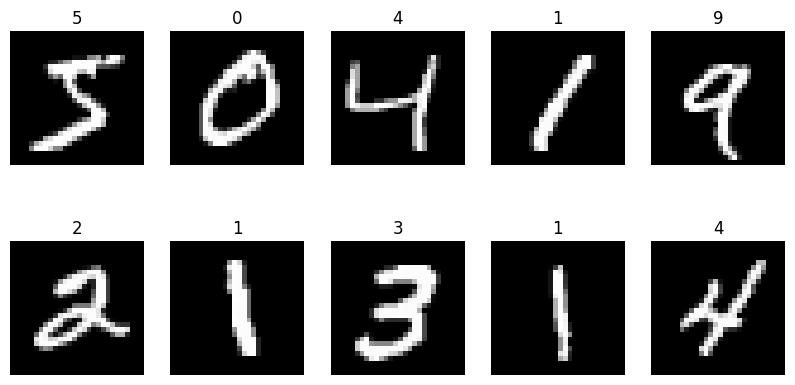

In [56]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(y_train[i])
    plt.axis("off")


plt.show()

In [57]:
X_train = X_train / 255.0 #Preprocess the Dataset (Normalization & Reshaping)
X_test = X_test / 255.0

X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)


from tensorflow import keras
#Convert Labels to One-Hot Encoding
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

In [58]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(60000, 28, 28, 1)
(60000, 10)
(10000, 28, 28, 1)
(10000, 10)


In [69]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Flatten(input_shape=(28,28)),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)                  │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [70]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [71]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9285 - loss: 0.2408 - val_accuracy: 0.9607 - val_loss: 0.1282
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9694 - loss: 0.1013 - val_accuracy: 0.9727 - val_loss: 0.0897
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9776 - loss: 0.0718 - val_accuracy: 0.9744 - val_loss: 0.0819
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9823 - loss: 0.0543 - val_accuracy: 0.9770 - val_loss: 0.0785
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9871 - loss: 0.0404 - val_accuracy: 0.9726 - val_loss: 0.0939


In [62]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Accuracy =", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9870 - loss: 0.0697
Accuracy = 0.9869999885559082


In [72]:
y_pred = model.predict(X_test)

pred = np.argmax(y_pred, axis=1)

print(pred[:10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[7 2 1 0 4 1 4 9 6 9]


In [73]:
prediction = model.predict(X_test)

index = 0

true = np.argmax(y_test[index])
pred = np.argmax(prediction[index])

print("True :", true)
print("Predicted :", pred)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
True : 7
Predicted : 7


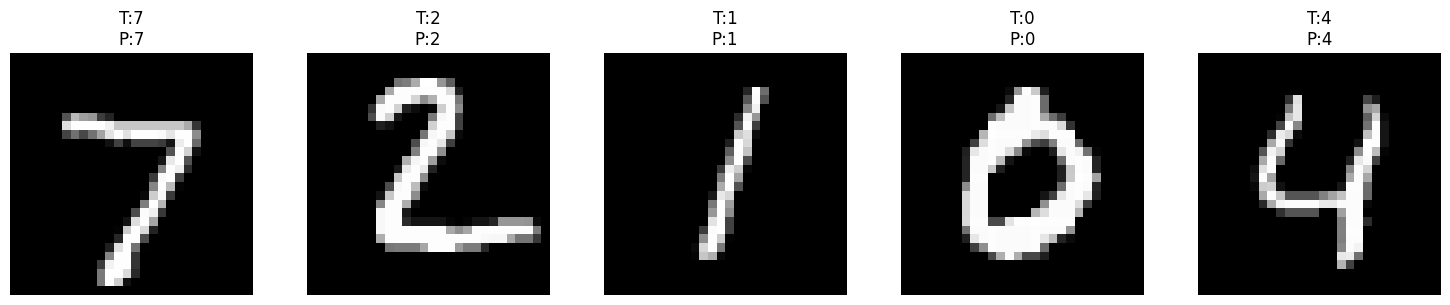

In [74]:
plt.figure(figsize=(15,3))

for i in range(5):
    true = np.argmax(y_test[i])
    pred = np.argmax(y_pred[i])

    plt.subplot(1,5,i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.title(f"T:{true}\nP:{pred}")
    plt.axis('off')

plt.tight_layout()
plt.show()

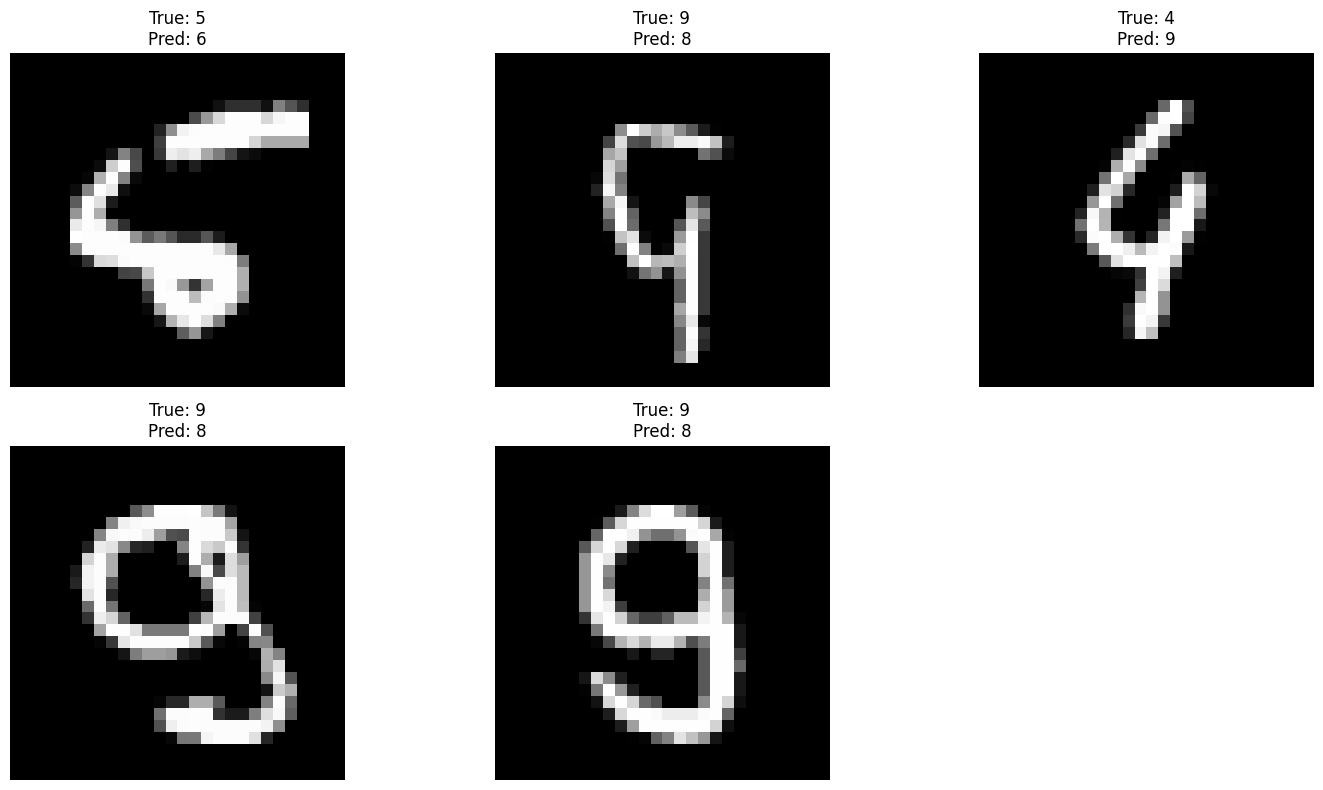

In [75]:
plt.figure(figsize=(15,8))

count = 0

for i in range(len(X_test)):
    true = np.argmax(y_test[i])
    pred = np.argmax(y_pred[i])

    if true != pred:
        count += 1

        plt.subplot(2,3,count)
        plt.imshow(X_test[i].reshape(28,28), cmap='gray')
        plt.title(f"True: {true}\nPred: {pred}")
        plt.axis('off')

        if count == 5:
            break

plt.tight_layout()
plt.show()

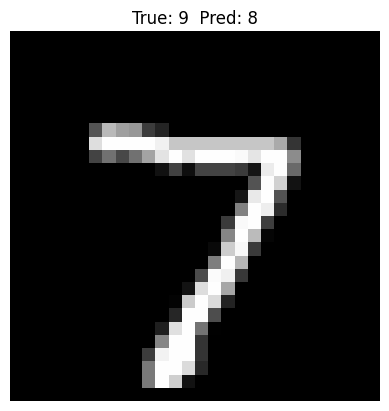

In [76]:
plt.imshow(X_test[index].reshape(28,28), cmap="gray")
plt.title(f"True: {true}  Pred: {pred}")
plt.axis("off")
plt.show()